### Programming for Biomedical Informatics
#### Week 6 - Differential Gene Expression Analysis

We're going to perform some differential expression analysis using the PyDESeq2 package using an RNA-Seq dataset from NCBI-GEO

In [ ]:
'''
Sources of Data

Original Publication
Tomaiuolo P, Piras IS, Sain SB, Picinelli C, Baccarin M, Castronovo P, Morelli MJ, Lazarevic D, Scattoni ML, Tonon G, Persico AM.
RNA sequencing of blood from sex- and age-matched discordant siblings supports immune and transcriptional dysregulation in autism spectrum disorder.
Sci Rep. 2023 Jan 16;13(1):807. doi: 10.1038/s41598-023-27378-w. PMID: 36646776; PMCID: PMC9842630.

GEO Entry: GSE212645
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE212645

meta-data file
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE212nnn/GSE212645/matrix/GSE212645_series_matrix.txt.gz

raw data file
https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE212645&format=file&file=GSE212645_filtered_counts_GRCh38.p13_NCBI.tsv.gz

normalised data file
https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE212645&format=file&file=GSE212645_norm_counts_FPKM_GRCh38.p13_NCBI.tsv.gz

genome annotation file
https://www.ncbi.nlm.nih.gov/geo/download/?format=file&type=rnaseq_counts&file=Human.GRCh38.p13.annot.tsv.gz

This study only found 2 differentially expressed genes, this study is a little bit sussy, but it is educationaly
'''

In [ ]:
# fetch the experimental data and meta-data

#setup
import urllib.request
import os
import pandas as pd
import matplotlib.pyplot as plt

# #fetch the count data
# counts_url = 'https://www.ncbi.nlm.nih.gov/geo/download/?type=rnaseq_counts&acc=GSE212645&format=file&file=GSE212645_raw_counts_GRCh38.p13_NCBI.tsv.gz'
# urllib.request.urlretrieve(counts_url, './data/GSE212645_raw_counts_GRCh38.p13_NCBI.tsv.gz')
raw_counts = pd.read_csv('./data/GSE212645_raw_counts_GRCh38.p13_NCBI.tsv.gz', sep='\t', index_col=0)

# #fetch the meta-data
# metadata_url = 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE212nnn/GSE212645/matrix/GSE212645_series_matrix.txt.gz'
# urllib.request.urlretrieve(metadata_url, './data/GSE212645_series_matrix.txt.gz')
# #read in the meta-data
# we need to skip the first 38 rows as they contain project rather than sample meta-data
metadata = pd.read_csv('./data/GSE212645_series_matrix.txt.gz', sep='\t', skiprows=38, header=None)


# we now tidy this up and retain the information we need
# keep the rows we need
row_numbers = [0,8,10,11,12]
metadata = metadata.iloc[row_numbers]

# replace column 0 values with the list below
new_feature_names = ['number','gender', 'status', 'family', 'treatment']
metadata.iloc[:,0] = new_feature_names

# make the first row the column names and remove the first row
metadata.columns = metadata.iloc[0]
metadata = metadata.iloc[1:]
metadata.set_index('number', append=False, inplace=True)

# # transpose the data frame
metadata = metadata.T

# # reset the index and rename the first column
metadata.reset_index(inplace=True)
metadata.rename(columns={0: 'sample_no'}, inplace=True)

# tidy up the column contents
metadata['gender'] = metadata['gender'].str.replace('Sex: ', '')
metadata['status'] = metadata['status'].str.replace('genotype: ', '')
metadata['family'] = metadata['family'].str.replace('family: ', '')
metadata['treatment'] = metadata['treatment'].str.replace('treatment: ', '')

metadata.set_index('sample_no', inplace=True)
metadata.index.name = None

#change index name to sample_id
metadata.index.name = 'sample_id'

In [ ]:
metadata.head()

## Family field is a way to link siblings together


number,gender,status,family,treatment
sample_id,,,,
GSM6542253,F,ASD,F1,no
GSM6542254,F,SIB,F1,no
GSM6542255,M,ASD,F2,no
GSM6542256,M,SIB,F2,no
GSM6542257,M,ASD,F3,no


In [5]:
# Keep only genes where all samples have counts >= 10
# In practice, you can do a voting and concensus more sensitive 
filtered_counts = raw_counts[(raw_counts >= 10).all(axis=1)]

# keep the mean counts of the removed genes to check later
# Keep things that were removed later to perhaps make reference later
removed_counts = raw_counts[(raw_counts <= 10).all(axis=1)]

# calculate the mean expression for each gene
removed_means = removed_counts.mean(axis=1)
removed_means = removed_means.sort_values(ascending=False)

#keep this for later

In [ ]:
# look at the count data
print(filtered_counts.shape)
filtered_counts.head()

## Big red flag is that we lost three quarters of the data during this filter


(14327, 40)


,GSM6542253,GSM6542254,GSM6542255,GSM6542256,GSM6542257,GSM6542258,GSM6542259,GSM6542260,GSM6542261,GSM6542262,...,GSM6542283,GSM6542284,GSM6542285,GSM6542286,GSM6542287,GSM6542288,GSM6542289,GSM6542290,GSM6542291,GSM6542292
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,265,88,204,178,360,458,350,183,251,134,...,88,22,12,200,42,64,31,30,24,188
653635,2267,478,1547,1677,1714,2297,4718,3009,725,631,...,420,227,339,1823,543,424,350,286,289,1823
100996442,290,331,1144,1096,1631,1313,2363,1204,306,377,...,185,89,350,1910,598,238,378,266,247,1426
729737,2063,2964,6524,5055,5963,5546,15144,8524,3635,3262,...,3974,1109,2589,7202,3917,1303,1364,1000,1260,7793
102723897,2451,518,1518,1860,1585,2064,4951,2827,749,638,...,499,257,386,1803,562,463,375,330,307,1699


In [8]:
# look at the meta-data
print(metadata.shape)
metadata.head()

(40, 4)


number,gender,status,family,treatment
sample_id,,,,
GSM6542253,F,ASD,F1,no
GSM6542254,F,SIB,F1,no
GSM6542255,M,ASD,F2,no
GSM6542256,M,SIB,F2,no
GSM6542257,M,ASD,F3,no


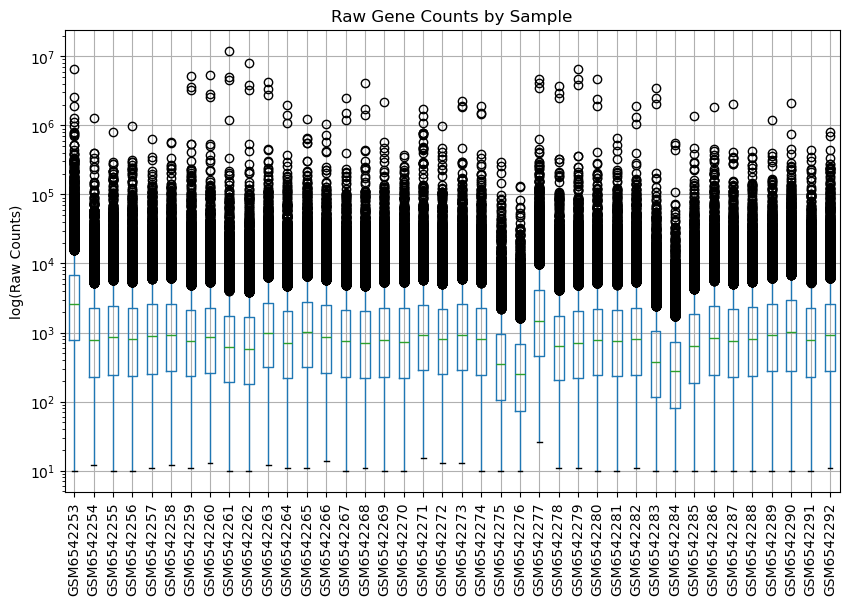

In [ ]:
# plot a boxplot of the raw counts by sample
plt.figure(figsize=(10,6))

filtered_counts.boxplot(rot=90)
plt.yscale('log')
plt.title('Raw Gene Counts by Sample')
plt.ylabel('log(Raw Counts)')
plt.show()


### Circles are outliers, 1000 counts is quite a low mean for example

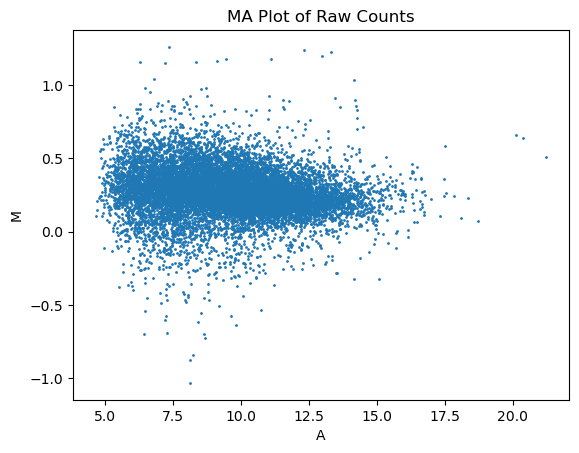

In [ ]:
# plot an MA plot of the raw counts from scratch

import numpy as np

# find all the columns in filtered_counts that have column headers matching the metadata index and have staus of 'ASD'ArithmeticError
asd_samples = metadata[metadata['status'] == 'ASD'].index

# find all the columns in filtered_counts that have column headers matching the metadata index and have staus of 'SIB'
sib_samples = metadata[metadata['status'] == 'SIB'].index

# calculate the mean of the raw counts for each gene in the ASD samples
asd_mean = filtered_counts[asd_samples].mean(axis=1)

# calculate the mean of the raw counts for each gene in the SIB samples
sib_mean = filtered_counts[sib_samples].mean(axis=1)

# create a new data frame with these mean values and the gene names as the index
ma_data = pd.DataFrame({'ASD': asd_mean, 'SIB': sib_mean})

# calculate the M value with log2
ma_data['M'] = ma_data['ASD'].apply(np.log2) - ma_data['SIB'].apply(np.log2)

# calculate the A value with log2
ma_data['A'] = (ma_data['ASD'].apply(np.log2) + ma_data['SIB'].apply(np.log2)) / 2

# plot the data
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(ma_data['A'], ma_data['M'], s=1)
plt.xlabel('A')
plt.ylabel('M')
plt.title('MA Plot of Raw Counts')
plt.show()

### Idea here is that most genes don't changes,
## Most of the data should be at zero, and then gene counts up and down 
## There is some weird shift, it is not centred around zero which can't be true

In [11]:
# Simple PCA analysis

### T-sne and UMAP can be done too, but we're using a standard two dimensional


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

transposed_filtered_counts = filtered_counts.T

# scale features, run PCA on 2-dimensions
X = transposed_filtered_counts.values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
sample_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=transposed_filtered_counts.index)

sample_pca = sample_pca.join(metadata['status'])

#visualise
sample_pca.index.name = 'sample_id'

print(sample_pca)

                   PC1         PC2 status
sample_id                                
GSM6542253  473.591626  -11.909091    ASD
GSM6542254  -10.413462  -27.984638    SIB
GSM6542255    9.104238  -49.051882    ASD
GSM6542256   -1.755094  -56.875419    SIB
GSM6542257   21.284872  -56.016308    ASD
GSM6542258   25.696115  -44.146254    SIB
GSM6542259  -25.430517    0.015229    ASD
GSM6542260   -3.875939  -17.549949    SIB
GSM6542261  -59.101841   23.169994    ASD
GSM6542262  -67.599790   26.098327    SIB
GSM6542263   51.847349   69.048693    ASD
GSM6542264  -30.673400   37.901896    SIB
GSM6542265   60.041276   21.105933    ASD
GSM6542266   10.836370   14.246822    SIB
GSM6542267  -22.086070    6.640494    ASD
GSM6542268  -27.222395   27.900050    SIB
GSM6542269   -7.726244  -17.463584    ASD
GSM6542270  -16.816089  -13.418483    SIB
GSM6542271   20.329978   20.707521    ASD
GSM6542272   -3.899120   25.539945    SIB
GSM6542273   24.548644   39.187724    ASD
GSM6542274   -9.683566   34.745601

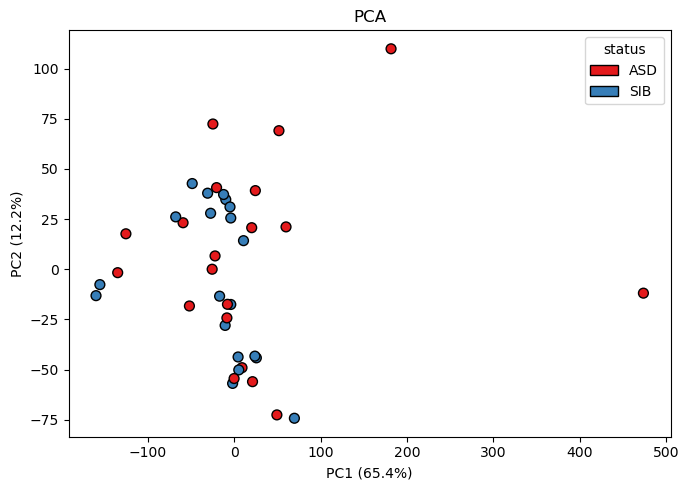

In [ ]:
# plot the pca
# THe principal comoponents are linear combination of the factos into orthoganol basis of pca1 and pca2
# THe plot below shows that 65% of variance are aligned along pc1 which is an issue
# We have noted 2 samples that are extreme, which you can take out
from matplotlib.patches import Patch

# map statuses to distinct colors
statuses = list(sample_pca['status'].unique())
cmap = plt.get_cmap('Set1')
color_map = {s: cmap(i % cmap.N) for i, s in enumerate(statuses)}
colors = sample_pca['status'].map(color_map)

# create figure and axes, scatter and attach colorbar to that axes
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(sample_pca['PC1'], sample_pca['PC2'], s=50, edgecolor='k',c=list(colors))

# simple legend with colored patches
legend_elements = [Patch(facecolor=col, edgecolor='k', label=label) 
                   for label, col in color_map.items()]
ax.legend(handles=legend_elements, title='status')

# labels and colorbar
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title('PCA')
plt.tight_layout()
plt.show()

In [13]:
# remove the outlier samples
samples_to_remove = ['GSM6542253', 'GSM6542277']

filtered_counts_good_samples = filtered_counts.drop(columns=samples_to_remove, errors='ignore')
print(filtered_counts_good_samples.shape)

metadata_good_samples = metadata.drop(index=samples_to_remove, errors='ignore')
print(metadata_good_samples.shape)

(14327, 38)
(38, 4)


In [17]:
# now lets use DESeq2 to perform differential expression

import os
import pickle as pkl

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import *

SAVE = False  # whether to save the outputs of this notebook

if SAVE:
    # Replace this with the path to directory where you would like results to be
    # saved
    OUTPUT_PATH = "./data/asd_deseq2_results"
    os.makedirs(OUTPUT_PATH, exist_ok=True)  # Create path if it doesn't exist

In [18]:
## set up the DESeq2 object
## Note we are setting up a two-factor (paired analysis) where disease status is assessed in sibling pairs affected:unaffected

inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=filtered_counts_good_samples.T,
    metadata=metadata_good_samples,
    design="~status+family",
    refit_cooks=True,
    inference=inference,
)

#ignore the error, this is just because the gene_ids are numbers

print(dds)

AnnData object with n_obs × n_vars = 38 × 14327
    obs: 'gender', 'status', 'family', 'treatment'
    obsm: 'design_matrix'


c:\Users\james\anaconda3\envs\bio_env\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [19]:
# compute normalisation factors
# This is the scaling for how well different experiments have workd
dds.fit_size_factors()

# extract the size factors to look at
size_factors = dds.obs["size_factors"]

# sort by value descending
size_factors.sort_values()

size_factors.columns = ['sizefactor']

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.



In [21]:
size_factors.head(20)
# Not too far from 1, those two chips would show up as 5, e.g. the counts don't look like any of the others

sample_id
GSM6542254    1.093892
GSM6542255    1.180107
GSM6542256    1.122848
GSM6542257    1.253968
GSM6542258    1.259598
GSM6542259    1.017532
GSM6542260    1.119799
GSM6542261    0.830170
GSM6542262    0.813257
GSM6542263    1.383917
GSM6542264    0.994329
GSM6542265    1.458181
GSM6542266    1.220313
GSM6542267    1.037950
GSM6542268    1.007011
GSM6542269    1.099433
GSM6542270    1.009977
GSM6542271    1.239010
GSM6542272    1.138022
GSM6542273    1.240354
Name: size_factors, dtype: float64

In [22]:
# fit gene-wise dispersion estimates
dds.fit_genewise_dispersions()

# fit dispersion priors
dds.fit_dispersion_prior()

Fitting dispersions...
... done in 4.99 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.



In [23]:
# have a look at the DESeq2 object after the fitting
print(dds)

AnnData object with n_obs × n_vars = 38 × 14327
    obs: 'gender', 'status', 'family', 'treatment', 'size_factors'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix'
    layers: 'normed_counts', '_mu_hat'


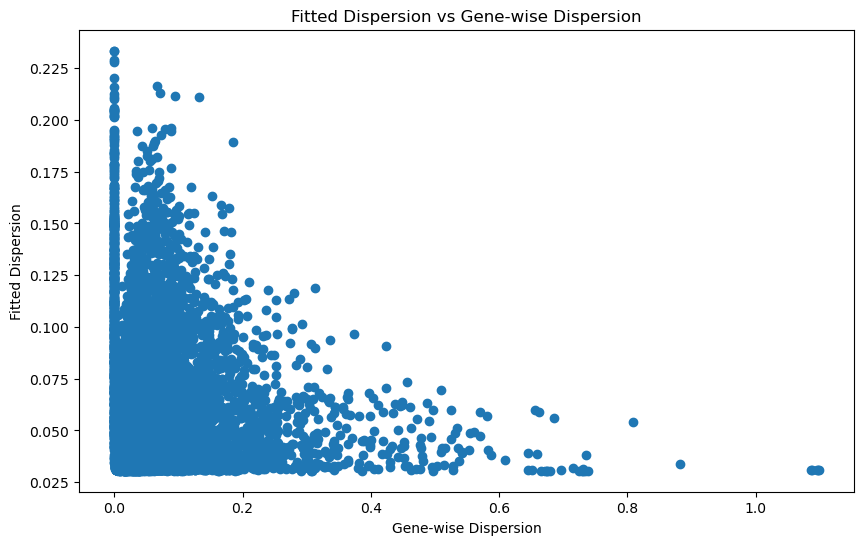

In [ ]:
# plot the fitted dispersion trend
plt.figure(figsize=(10,6))
plt.scatter(dds.var['genewise_dispersions'], dds.var['fitted_dispersions'])
# plt.scatter(dds.var['genewise_dispersions'], dds.var['fitted_dispersions'])
plt.xlabel('Gene-wise Dispersion')
plt.ylabel('Fitted Dispersion')
plt.title('Fitted Dispersion vs Gene-wise Dispersion')
plt.show()

# OK this looks very problematic, remember fitted vs gene dispersion should be a linear relationship - this is a red flag
# It has converged, but this is not a good fit

In [25]:
# fit log fold changes
dds.fit_LFC()
lfcs = dds.varm["LFC"]

Fitting MAP dispersions...
... done in 6.21 seconds.

Fitting LFCs...
... done in 3.18 seconds.



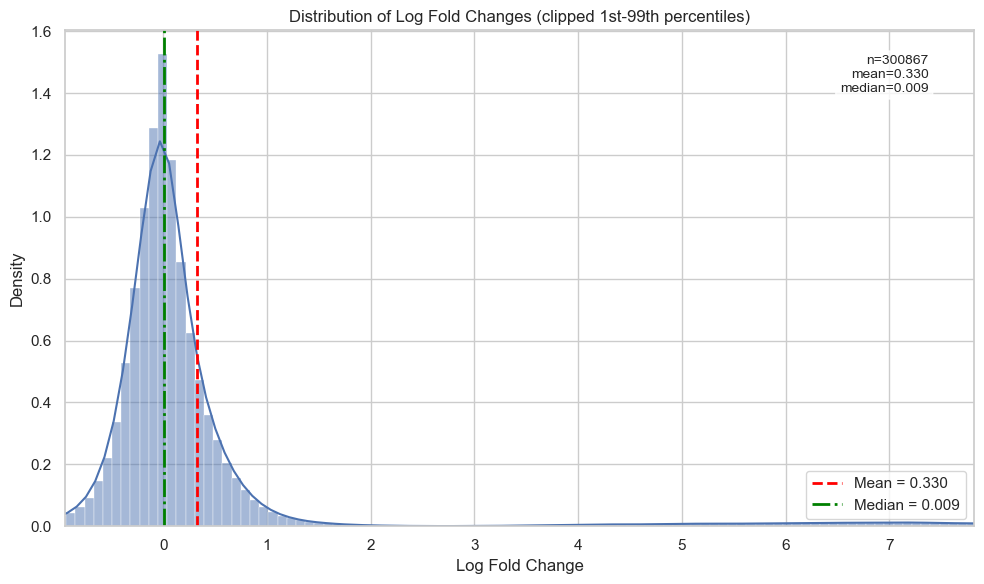

In [ ]:
# Improved plot for log fold changes using seaborn style
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# flatten lfcs if it's an array-like
lfcs_arr = np.array(lfcs).ravel()

# compute robust x-limits (1st to 99th percentiles) to avoid extreme outliers
vmin = np.nanpercentile(lfcs_arr, 1)
vmax = np.nanpercentile(lfcs_arr, 99)

plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid')

# plot histogram with KDE overlay, clipped to the percentile range for display
sns.histplot(lfcs_arr, bins=200, kde=True, stat='density', color='C0')
plt.xlim(vmin, vmax)

# annotate mean and median
mean_val = np.nanmean(lfcs_arr)
median_val = np.nanmedian(lfcs_arr)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.3f}')
plt.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median = {median_val:.3f}')

plt.xlabel('Log Fold Change')
plt.ylabel('Density')
plt.title('Distribution of Log Fold Changes (clipped 1st-99th percentiles)')
plt.legend()

# add a small text box with summary stats
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(0.95, 0.95, f'n={lfcs_arr.size}\nmean={mean_val:.3f}\nmedian={median_val:.3f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

# The log fold chain distribution does not look that bad, but nearly everything is positive
# There are some highly expressed genes, but we know that we basically corrected that ourselves
# Look at the MA plot above, this should be zero distributed

In [27]:
# calculate cooks distanes and refit

# this step aims to identify outliers that would adversely affect the differential expresison analysis and filters them out
dds.calculate_cooks()
if dds.refit_cooks:
    # Replace outlier counts
    dds.refit()

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 0 outlier genes.



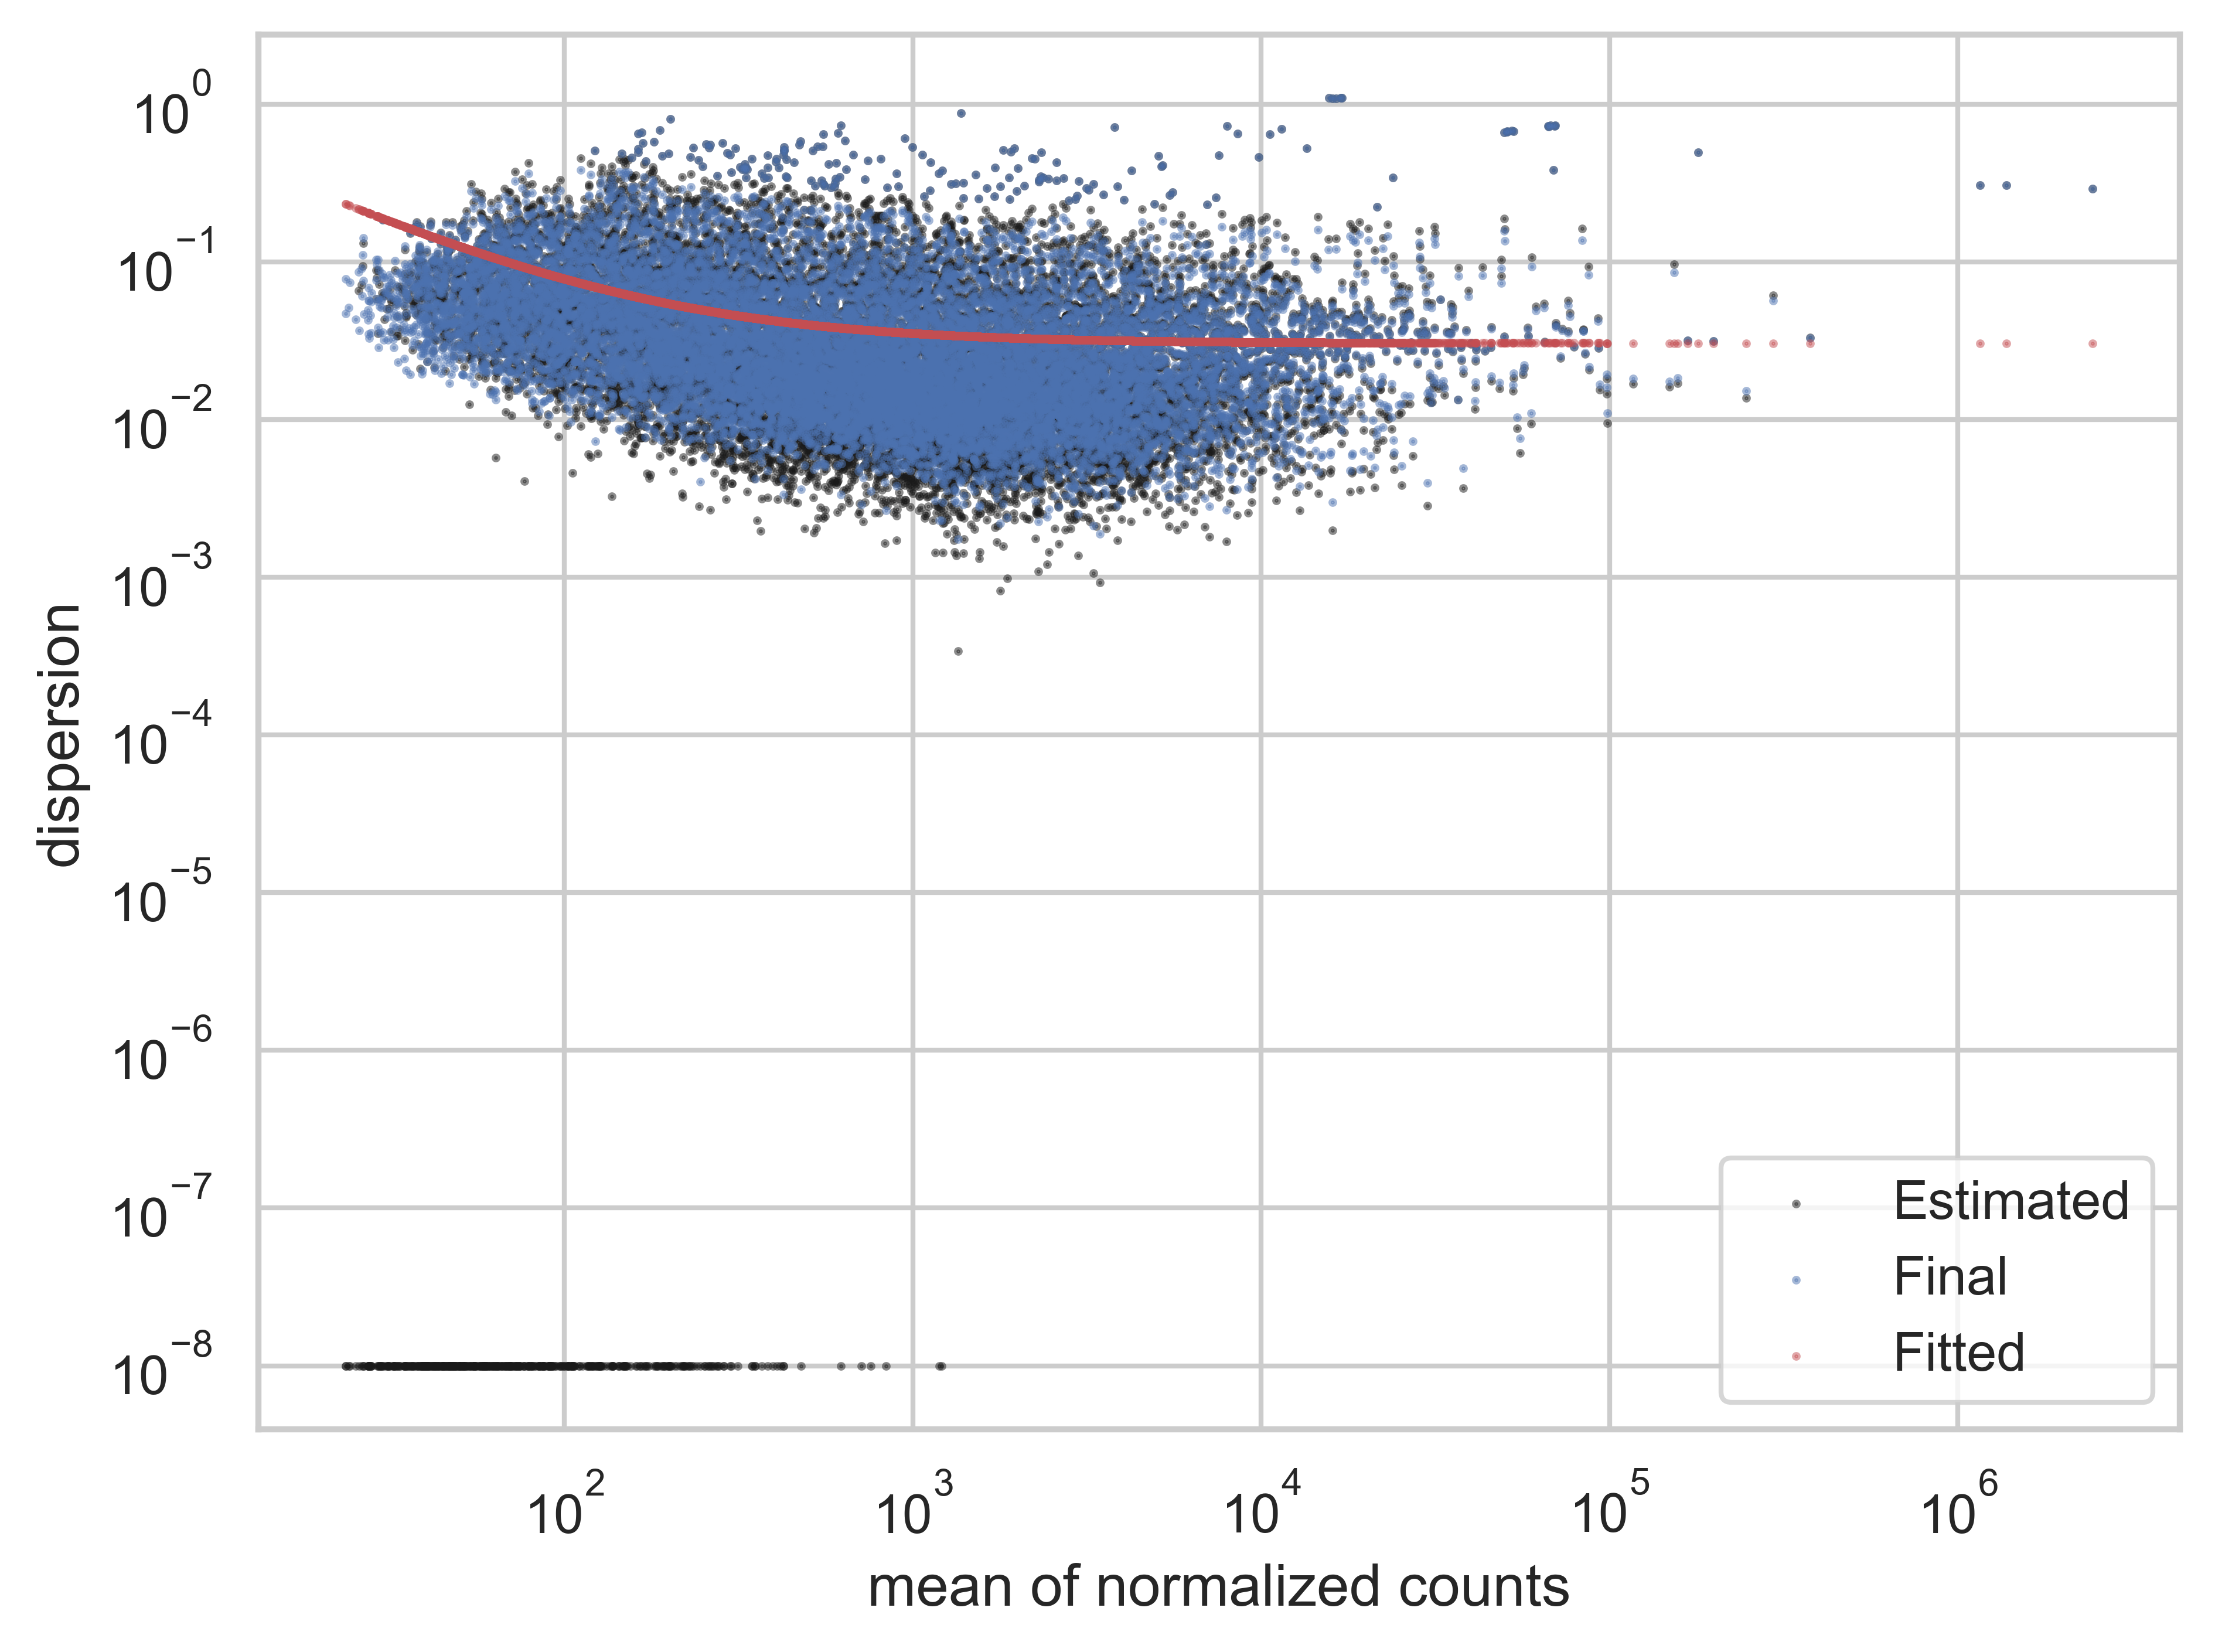

In [ ]:
#let's look at the dispersion plot
dds.plot_dispersions()

# this looks OK, but is very flat, an unusually low amount of dispersion especially at the high count end

## Looks similar to tuesday, it is very flat, there is not a relationship between dispersion and count
## we don't see this techincal non heteroskepdascity thing going on

In [31]:
# save the results so far
if SAVE:
    with open(os.path.join(OUTPUT_PATH, "dds_detailed_pipe.pkl"), "wb") as f:
        pkl.dump(dds, f)

In [32]:
# this is the main step where the differential expression is calculated
stat_res = DeseqStats(dds, contrast=['status','ASD','SIB'], inference=inference)

In [33]:
# create the summary stats
# runs the Wald test
# this test effectively calculates the robustness of the beta value estaimation in the main DESeq2 GLM and then calculates the p-values based on the aussume
# assumed normal distribution of the beta values

stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: status ASD vs SIB
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
GeneID                                                                  
100287102    126.777460       -0.220853  0.271992 -0.811984  0.416801   
653635       975.941995       -0.245465  0.204478 -1.200449  0.229965   
100996442    643.065817       -0.125780  0.226361 -0.555661  0.578442   
729737      5466.404122        0.108602  0.248544  0.436954  0.662145   
102723897   1015.118654       -0.219589  0.193336 -1.135790  0.256045   
...                 ...             ...       ...       ...       ...   
4541       28802.596604        0.081292  0.088570  0.917829  0.358708   
4556        2259.939802        0.093062  0.102065  0.911793  0.361878   
4519       84175.180283        0.026404  0.091973  0.287091  0.774043   
4576         191.073368       -0.076871  0.182653 -0.420860  0.673857   
4571         222.351258        0.193462  0.122924  1.573827  0.11552

... done in 1.24 seconds.



In [ ]:
results = stat_res.results_df

sorted_results = results.sort_values(by='pvalue', ascending=True)

#convert the GeneID column to integers
sorted_results.index = sorted_results.index.map(int)
sorted_results.reset_index(inplace=True)

sorted_results.head()

# it's clear here that the p-value adjustment is very heavily penalising the p-values
## Only one pass the p-value, and the adjustment lost a four fold thing
t## THe variance across the genes are huge


,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,9902,93.641589,0.602198,0.116774,5.156944,2.510132e-07,0.003596
1,220906,1414.929015,-0.174530,0.040169,-4.344909,1.393333e-05,0.099811
2,102723390,80.064093,-0.779287,0.188575,-4.132503,3.588347e-05,0.171368
3,8531,5513.292080,0.486100,0.121210,4.010402,6.061558e-05,0.194326
4,90990,377.178816,0.403691,0.102876,3.924052,8.707193e-05,0.194326


In [ ]:
# optionally save the results
# if SAVE:
#     with open(os.path.join(OUTPUT_PATH, "stat_results_detailed_pipe.pkl"), "wb") as f:
#         pkl.dump(stat_res, f)

In [35]:
# load up the genome annotation file so that we can look at the gene names
# THe paper talks about 6 genes

annotation_url = 'https://www.ncbi.nlm.nih.gov/geo/download/?format=file&type=rnaseq_counts&file=Human.GRCh38.p13.annot.tsv.gz'

# download the file and save in the ./data directory
import urllib.request
import os

urllib.request.urlretrieve(annotation_url, './data/Human.GRCh38.p13.annot.tsv.gz')

#read directly into a data frame
annotation = pd.read_csv('./data/Human.GRCh38.p13.annot.tsv.gz', sep='\t', index_col=0, low_memory=False)

#drop all columns except Symbol and Description
annotation = annotation[['Symbol', 'Description']]

annotation.head()

,Symbol,Description
GeneID,,
100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene)
653635,WASH7P,"WASP family homolog 7, pseudogene"
102466751,MIR6859-1,microRNA 6859-1
107985730,MIR1302-2HG,MIR1302-2 host gene
100302278,MIR1302-2,microRNA 1302-2


In [ ]:
# merge the annotation with the results on the GeneID column
results = sorted_results.merge(annotation, left_on='GeneID', right_on='GeneID')

results.head(20)

## This shows us that the top differentially expressed genes have nothing to do with autism

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description
0,9902,93.641589,0.602198,0.116774,5.156944,2.510132e-07,0.003596,MRC2,mannose receptor C type 2
1,220906,1414.929015,-0.174530,0.040169,-4.344909,1.393333e-05,0.099811,WAC-AS1,WAC antisense RNA 1 (head to head)
2,102723390,80.064093,-0.779287,0.188575,-4.132503,3.588347e-05,0.171368,FRG1EP,"FSHD region gene 1 family member E, pseudogene"
3,8531,5513.292080,0.486100,0.121210,4.010402,6.061558e-05,0.194326,YBX3,Y-box binding protein 3
4,90990,377.178816,0.403691,0.102876,3.924052,8.707193e-05,0.194326,KIFC2,kinesin family member C2
5,105375754,292.768415,-0.498796,0.127508,-3.911868,9.158486e-05,0.194326,LOC105375754,uncharacterized LOC105375754
6,401647,529.338317,0.254602,0.065230,3.903158,9.494550e-05,0.194326,GOLGA7B,golgin A7 family member B
7,8991,726.179103,0.826924,0.215192,3.842722,1.216773e-04,0.217909,SELENBP1,selenium binding protein 1
8,2289,7258.156467,-0.321957,0.087022,-3.699728,2.158309e-04,0.343579,FKBP5,FKBP prolyl isomerase 5
9,10046,35.162941,0.532578,0.147892,3.601129,3.168385e-04,0.371273,MAMLD1,mastermind like domain containing 1


In [38]:
# now lets go back and pick up the results for the genes cited in the paper to see what the p-values are
# Three of the symbols here don't even show up in the data, which is very surprising!
target_genes = ['EGR1', 'EGR2', 'IGKV6D-21', 'IGKV3D-15', 'S100B', 'CD80']

target_gene_results = results[results['Symbol'].isin(target_genes)]

target_gene_results

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description
86,6285,306.995748,-0.699344,0.246237,-2.840130,0.004510,0.689073,S100B,S100 calcium binding protein B
3266,1958,145.157452,0.305843,0.242930,1.258976,0.208039,0.909308,EGR1,early growth response 1
13222,28875,292.753078,0.033441,0.339797,0.098415,0.921603,0.998039,IGKV3D-15,immunoglobulin kappa variable 3D-15


In [39]:
#lets go back and find the log normlised counts for these genes
# merge the ma_data with the target_gene_results on the GeneID column

combined = target_gene_results.merge(ma_data, left_on='GeneID', right_index=True)

combined.head(10)

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,ASD,SIB,M,A
86,6285,306.995748,-0.699344,0.246237,-2.840130,0.004510,0.689073,S100B,S100 calcium binding protein B,196.80,402.35,-1.031721,8.136447
3266,1958,145.157452,0.305843,0.242930,1.258976,0.208039,0.909308,EGR1,early growth response 1,253.25,105.75,1.259905,7.354466
13222,28875,292.753078,0.033441,0.339797,0.098415,0.921603,0.998039,IGKV3D-15,immunoglobulin kappa variable 3D-15,339.90,265.35,0.357214,8.230360


In [40]:
# we can only display data from genes that made it through our earlier QC
surviving_target_genes = set(target_genes) & set(combined['Symbol'])
missing_genes = set(target_genes) - set(combined['Symbol'])

In [ ]:
# out of interest here are the mean counts for the target genes that were excluded earlier!

# Filter annotation to find genes in missing_genes
missing_gene_info = annotation[annotation['Symbol'].isin(list(missing_genes))]
missing_gene_counts = pd.merge(missing_gene_info,raw_counts,on='GeneID')

# Calculate mean of columns from the 3rd column onwards (columns 2+, 0-indexed)
missing_gene_counts['Mean'] = missing_gene_counts.iloc[:, 2:].mean(axis=1)

# Display the results
print(missing_gene_counts[['Symbol', 'Mean']])


### 10-50 million reads per sample, these genes are barely expressed, so there is no way to measures about thes expressed changes

           Symbol    Mean
GeneID                   
28870   IGKV6D-21  39.050
941          CD80  31.850
1959         EGR2  49.125


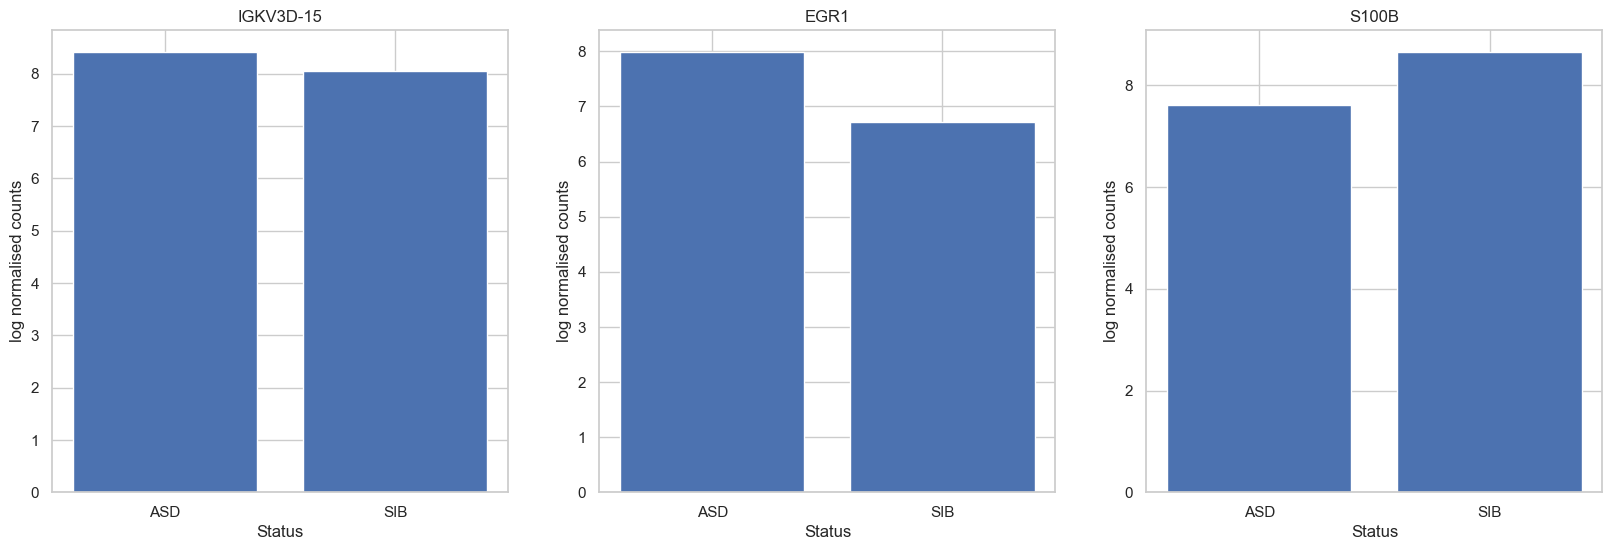

In [42]:
# next we plot paired barcharts for each Symbol showing the log normalised counts for each gene in the ASD and SIB samples using matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, len(surviving_target_genes), figsize=(20, 6))

for i, gene in enumerate(surviving_target_genes):
    #take the log2 values of the counts
    combined.loc[combined['Symbol'] == gene, ['ASD', 'SIB']] = combined.loc[combined['Symbol'] == gene, ['ASD', 'SIB']].apply(np.log2)
    ax[i].bar(['ASD', 'SIB'], combined.loc[combined['Symbol'] == gene, ['ASD', 'SIB']].values[0])
    ax[i].set_title(gene)
    ax[i].set_ylabel('log normalised counts')
    ax[i].set_xlabel('Status')

plt.show()

# the trends are the same as in the paper, but the p-values are not significant - NB in the paper only EGR1 and IGKV3D-15 were significant after correction.

### Results:
There is something fundamentally wrong with the experiment
- Counts are low so perhaps the technical implementatoin was poor
- You may need better sequencing instead of 